# From ECG to HR and simple HRV (Principles: vagal tone, RSA)

## TODOs

1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

## My notes

+ RMSSD (Root Mean Square of Successive Differences)
    - Calculate using the R-peaks, where these R-peaks are the heartbeats.
    - R-peaks come from ECG, where ECG has P-wave, QRS-complex, and T-wave.
    - Time domain.
    - Steps:
        1. Collect ECG
        2. Delineate ECG for R-peaks
        3. Calculate RMSSD by passing in R-peaks
    - We want this value to be
        1. high bc it leads to better recovery + more ANS stimulaton?
            - high means more time between heartbeats
        2. varied bc it leads to better recovery
+ HF (High Frequency) power
    1. Frequency domain.
    2. Favors parasympathetic activity, which is rest and recovery/digest.
    3. We want this value to be high bc...

## Code

In [1]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

In [2]:
def load_wesad_subject(pkl_path: str):
    """Return dict with 'signal', 'label', plus any metadata present."""
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')  # WESAD often needs latin1
    # Normalize a few expected top-level keys if available
    out = {'raw': data}
    # Try common patterns
    for k in ['signal', 'signals', 'data']:
        if k in data:
            out['signal'] = data[k]
            break
    if 'label' in data:
        out['label'] = data['label']
    elif 'labels' in data:
        out['label'] = data['labels']
    return out

def summarize_structure(s):
    print("Top-level keys:", list(s['raw'].keys()))
    sig = s.get('signal', {})
    print("Signal namespaces:", list(sig.keys()))
    for ns, v in sig.items():
        if isinstance(v, dict):
            print(f"  [{ns}] channels:", list(v.keys()))
            for ch, arr in v.items():
                try:
                    print(f"    - {ch}: shape={np.array(arr).shape}, dtype={np.array(arr).dtype}")
                except Exception:
                    print(f"    - {ch}: (non-array)")
    if 'label' in s:
        lab = np.array(s['label']).squeeze()
        print("Labels shape:", lab.shape, "| unique:", np.unique(lab))

In [3]:
path_to_pkl = '../../../roeh-health/data/WESAD/per_subject/S7/S7.pkl'
S = load_wesad_subject(path_to_pkl)
summarize_structure(S)

Top-level keys: ['signal', 'label', 'subject']
Signal namespaces: ['chest', 'wrist']
  [chest] channels: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
    - ACC: shape=(3666600, 3), dtype=float64
    - ECG: shape=(3666600, 1), dtype=float64
    - EMG: shape=(3666600, 1), dtype=float64
    - EDA: shape=(3666600, 1), dtype=float64
    - Temp: shape=(3666600, 1), dtype=float32
    - Resp: shape=(3666600, 1), dtype=float64
  [wrist] channels: ['ACC', 'BVP', 'EDA', 'TEMP']
    - ACC: shape=(167616, 3), dtype=float64
    - BVP: shape=(335232, 1), dtype=float64
    - EDA: shape=(20952, 1), dtype=float64
    - TEMP: shape=(20952, 1), dtype=float64
Labels shape: (3666600,) | unique: [0 1 2 3 4 5 6 7]


In [4]:
S

{'raw': {'signal': {'chest': {'ACC': array([[ 1.06960011, -0.014     ,  1.4612    ],
           [ 1.06539989, -0.01020002,  1.42219996],
           [ 1.06539989,  0.00419998,  1.32019997],
           ...,
           [ 0.84660006, -0.10820001, -0.05739999],
           [ 0.84220004, -0.11379999, -0.08139998],
           [ 0.83340001, -0.11519998, -0.10259998]], shape=(3666600, 3)),
    'ECG': array([[-0.01922607],
           [-0.01693726],
           [-0.01615906],
           ...,
           [ 0.08638   ],
           [ 0.13993835],
           [ 0.23899841]], shape=(3666600, 1)),
    'EMG': array([[-0.04884338],
           [-0.00700378],
           [ 0.07177734],
           ...,
           [ 0.19976807],
           [ 0.22764587],
           [ 0.21807861]], shape=(3666600, 1)),
    'EDA': array([[12.50686646],
           [12.46871948],
           [12.50686646],
           ...,
           [13.09013367],
           [13.08135986],
           [13.08021545]], shape=(3666600, 1)),
    'Temp': ar

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

def rr_from_ecg(ecg, fs, min_rr=0.3, max_rr=2.0):
    """Very simple R-peak detection + RR intervals (seconds)."""
    x = (ecg - np.median(ecg)) / (np.std(ecg) + 1e-9)
    peaks, _ = find_peaks(x, distance=int(min_rr*fs), prominence=np.std(x)*0.5)
    rr = np.diff(peaks) / fs
    rr = rr[(rr > min_rr) & (rr < max_rr)]
    return peaks, rr

def hrv_time(rr):
    """Basic time-domain HRV: SDNN, RMSSD, pNN50."""
    rr_ms = rr * 1000.0
    sdnn = np.std(rr_ms, ddof=1)
    diff = np.diff(rr_ms)
    rmssd = np.sqrt(np.mean(diff**2))
    pnn50 = np.mean(np.abs(diff) > 50.0) * 100.0
    return {'SDNN_ms': sdnn, 'RMSSD_ms': rmssd, 'pNN50_%': pnn50}

def hrv_freq(rr, fs_interp=4.0):
    """Welch PSD on interpolated tachogram → LF/HF power."""
    t = np.cumsum(rr)
    t = t - t[0]
    f = interp1d(t, rr, kind='linear', fill_value="extrapolate")
    t_even = np.arange(0, t[-1], 1.0/fs_interp)
    rr_even = f(t_even)
    rr_even = (rr_even - np.mean(rr_even))
    fxx, pxx = welch(rr_even, fs=fs_interp, nperseg=min(256, len(rr_even)))
    
    def band_power(fb):
        idx = np.logical_and(fxx >= fb[0], fxx < fb[1])
        return np.trapz(pxx[idx], fxx[idx])
    
    lf = band_power((0.04, 0.15))
    hf = band_power((0.15, 0.40))
    return {'LF': lf, 'HF': hf, 'LF_HF': (lf / hf) if hf > 0 else np.nan}

def plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx, segment_duration=10):
    """
    Plot a single ECG segment with detected R-peaks.
    
    Parameters
    ----------
    ecg : array_like
        The ECG signal data.
    peaks : array_like
        Indices of detected R-peaks.
    fs_ecg : float
        Sampling frequency of the ECG signal.
    segment_idx : int
        Index of the segment to plot (0-based).
    segment_duration : int, optional
        Duration of each segment in seconds (default is 10).
    
    Returns
    -------
    None
    """
    t_ecg = np.arange(len(ecg)) / fs_ecg
    
    start_idx = segment_idx * int(segment_duration * fs_ecg)
    end_idx = (segment_idx + 1) * int(segment_duration * fs_ecg)
    
    # Ensure we don't exceed the signal length
    if start_idx >= len(ecg):
        print(f"Segment {segment_idx + 1} exceeds signal length")
        return
    end_idx = min(end_idx, len(ecg))
    
    # Get the segment
    t_segment = t_ecg[start_idx:end_idx]
    ecg_segment = ecg[start_idx:end_idx]
    
    # Get peaks within this segment
    pk_segment = peaks[(peaks >= start_idx) & (peaks < end_idx)]
    
    # Plot
    plt.figure(figsize=(12, 3))
    plt.plot(t_segment, ecg_segment, lw=0.7)
    plt.plot(t_ecg[pk_segment], ecg[pk_segment], 'ro', ms=4)
    plt.title(f"ECG segment {segment_idx + 1} (seconds {segment_idx*segment_duration} to {(segment_idx+1)*segment_duration})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- pick ECG from chest or BVP from wrist as proxy if ECG missing ---
sig = S.get('signal', {})
ecg = None; fs_ecg = None

# Heuristic channel search
for ns in ['chest', 'wrist']:
    if ns in sig:
        for ch in sig[ns]:
            name = ch.lower()
            if 'ecg' in name:
                ecg = np.asarray(sig[ns][ch]).squeeze()
                fs_ecg = 700.0  # Use correct sampling rate from WESAD
                source = f"{ns}:{ch}"
                break
    if ecg is not None:
        break

Detected 6398 R-peaks from chest:ECG. RR count=6360

Time-domain HRV: {'SDNN_ms': np.float64(187.07516562539766), 'RMSSD_ms': np.float64(136.0521448171799), 'pNN50_%': np.float64(38.76395659694921)}

Freq-domain HRV: {'LF': np.float64(0.004501608364704172), 'HF': np.float64(0.003036357620010774), 'LF_HF': np.float64(1.4825685667053272)}


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_91902/2181405460.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


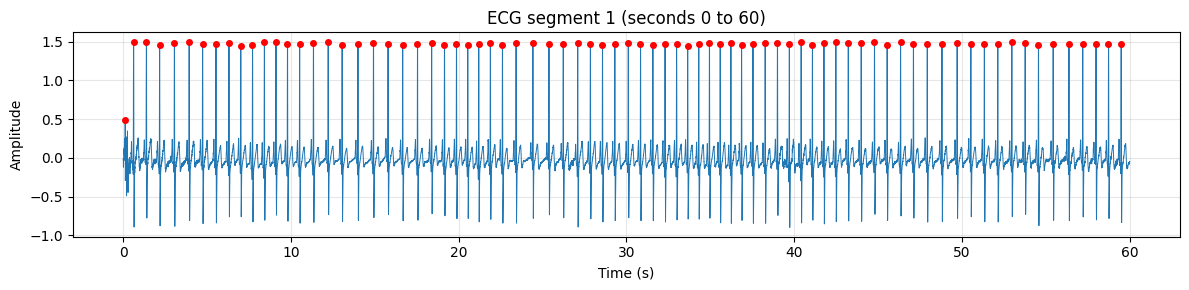

In [14]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=0, segment_duration=60)
else:
    print("No ECG channel found.")

Detected 6398 R-peaks from chest:ECG. RR count=6360

Time-domain HRV: {'SDNN_ms': np.float64(187.07516562539766), 'RMSSD_ms': np.float64(136.0521448171799), 'pNN50_%': np.float64(38.76395659694921)}

Freq-domain HRV: {'LF': np.float64(0.004501608364704172), 'HF': np.float64(0.003036357620010774), 'LF_HF': np.float64(1.4825685667053272)}


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_91902/2181405460.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


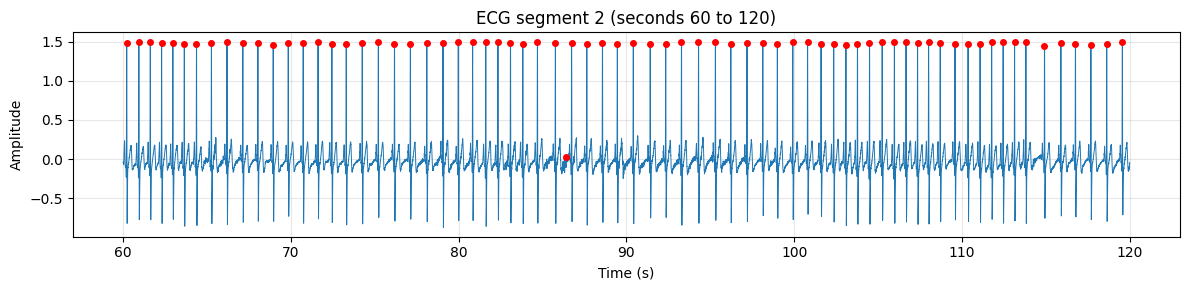

In [15]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=1, segment_duration=60)
else:
    print("No ECG channel found.")

Detected 6398 R-peaks from chest:ECG. RR count=6360

Time-domain HRV: {'SDNN_ms': np.float64(187.07516562539766), 'RMSSD_ms': np.float64(136.0521448171799), 'pNN50_%': np.float64(38.76395659694921)}

Freq-domain HRV: {'LF': np.float64(0.004501608364704172), 'HF': np.float64(0.003036357620010774), 'LF_HF': np.float64(1.4825685667053272)}


/var/folders/78/9z0b45fx1xqbwxh8vk97lcfh0000gn/T/ipykernel_91902/2181405460.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(pxx[idx], fxx[idx])


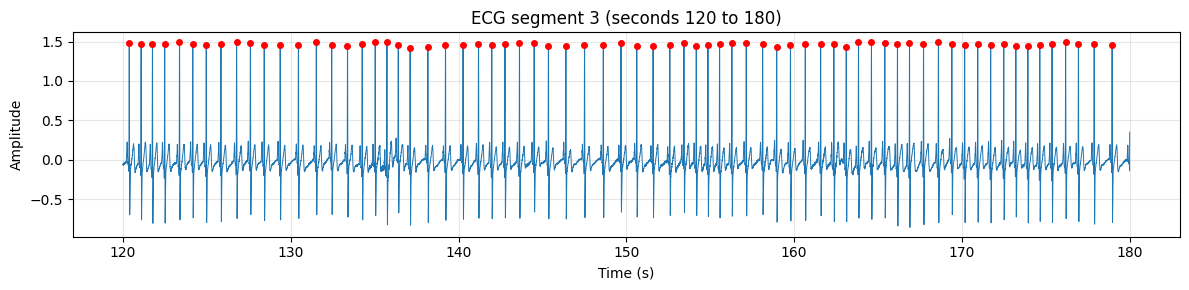

In [16]:
if ecg is not None:
    peaks, rr = rr_from_ecg(ecg, fs_ecg)
    print(f"Detected {len(peaks)} R-peaks from {source}. RR count={len(rr)}\n")
    print(f"Time-domain HRV: {hrv_time(rr)}\n")
    print(f"Freq-domain HRV: {hrv_freq(rr)}")
    
    # Plot each segment separately
    plot_ecg_segment(ecg, peaks, fs_ecg, segment_idx=2, segment_duration=60)
else:
    print("No ECG channel found.")

> - With the code above, I see that the image or the figure is showing roughly 10 seconds. Are we saying that the entirety of this subject's data is 10 seconds, or we sample only 10 seconds from this subject's data? If the letter of sample is only 10 seconds, then how can I sample another 10 seconds? I don't fully understand the code given to me. Base your comments direct on my statements and questions line by line.

## Follow-Up

> - Be sure to see TODOs

1. What do we gather from this subject?
2. Is there anything to flag?
3. 'RMSSD_ms': np.float64(698.4470516017469)
    - Why?
    - Good/Bad?
4. 'HF': np.float64(0.04114562090390898), why?
    - Why?
    - Good/Bad?
5. RMSSD_ms and HF considered jointly
    - If one is good and other bad? Vice versa
    - If both are good? Both are bad?

### 1. What do we gather from this subject?

> - R-peaks (aka heartbeats in orange).
> - There exists four high heartbeats and 11 lower-valued heartbeats.